# GRB Cosmic Merger Rate Density

Converts BNS and BHNS formation efficiencies into **intrinsic merger rate density R(z) [Gpc⁻³ yr⁻¹]** vs redshift, properly accounting for delay times between stellar birth and compact object merger.

Uses the Neijssel et al. (2019) MSSFR model (Madau & Dickinson 2014 SFR + log-normal metallicity evolution) from the COMPAS `FastCosmicIntegration` post-processing library.

**Run `GRB_BNS.ipynb` and `GRB_BHNS.ipynb` first** to verify the underlying classifications.

## 1. Imports

In [90]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.interpolate import interp1d

sys.path.insert(0, '/Users/josephrodriguez/research visualization/COMPAS')
from compas_python_utils.cosmic_integration.FastCosmicIntegration import (
    calculate_redshift_related_params,
    find_sfr,
    find_metallicity_distribution,
)

## 2. Cosmological Grid & MSSFR Model

Neijssel et al. (2019) parameters: `mu0=0.035`, `muz=-0.23`, `sigma0=0.39`.  
`redshift_step=0.01` gives 1001 points - sufficient resolution for rate vs redshift plots.

In [91]:
redshifts, n_z_detect, times, time_first_SF, distances, shell_volumes = \
    calculate_redshift_related_params(max_redshift=10.0, redshift_step=0.01)

sfr     = find_sfr(redshifts)
dPdlogZ, metallicities, p_draw = find_metallicity_distribution(
    redshifts,
    min_logZ_COMPAS=np.log(0.0001),
    max_logZ_COMPAS=np.log(0.03),
)
print(f"Redshift grid:  {len(redshifts)} points  (0 → {redshifts.max():.0f})")
print(f"time_first_SF:  {time_first_SF:.1f} Myr")
print(f"times range:    {times.min():.1f} – {times.max():.1f} Myr")
print(f"dPdlogZ shape:  {dPdlogZ.shape}")

Redshift grid:  1001 points  (0 → 10)
time_first_SF:  471.4 Myr
times range:    471.4 – 13786.9 Myr
dPdlogZ shape:  (1001, 1201)


## 3. Memory-Efficient Merger Rate Function

`find_formation_and_merger_rates` in COMPAS allocates an `(n_binaries × n_redshifts)` array which  
crashes the kernel for large populations. This replacement accumulates the sum directly, using only  
O(n_redshifts) memory regardless of population size.

**Bug note:** `t_min` must use `times.min()` (age at z_max ≈ 471 Myr), NOT `times[0]` (age at  
z=0 ≈ 13,787 Myr). The `times` array is monotonically *decreasing* (higher z → earlier universe).

In [92]:
def compute_merger_rate(redshifts, times, time_first_SF, n_formed,
                        dPdlogZ, metallicities, p_draw,
                        COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Memory-efficient intrinsic merger rate density [Gpc⁻³ yr⁻¹] vs redshift.

    For each binary: formation_rate(z) = SFR(z) × dP/dlogZ(z,Z_i) / p_draw × weight_i / meanMassEvolved
    The merger rate at z_merge is the formation rate at the redshift when the binary was born
    (z_form = redshift at age = t(z_merge) - delay_time).
    """
    n_z           = len(redshifts)
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)   # handles decreasing times correctly

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)

    # times is DECREASING (times[0]=age_z0≈13787 Myr, times[-1]=age_zmax≈471 Myr)
    # t_min must be the *smallest* time in the grid (times.min()), not times[0]
    t_min = max(time_first_SF, times.min())

    total_merger = np.zeros(n_z)

    for i in range(len(COMPAS_delay_times)):
        form_i = n_formed * dPdlogZ[:, Z_bins[i]] / p_draw * COMPAS_weights[i]

        t_form = times - COMPAS_delay_times[i]

        # Only process merger redshifts where formation time is within the grid
        valid = (t_form >= t_min)
        if not valid.any():
            continue

        j_idx      = np.where(valid)[0]
        z_form     = times_to_z(t_form[j_idx])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int), 0, n_z - 1)
        total_merger[j_idx] += form_i[z_form_idx]

    return total_merger

## 4. BNS: Load Data & Classify

Gottlieb et al. (2023) hybrid classification: `M_crit = 2.8 M☉`, `q_threshold = 1.2`.

In [93]:
path_BNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_A.h5'
with h5.File(path_BNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1           = fDCO['M1'][...].squeeze()
    mass2           = fDCO['M2'][...].squeeze()
    weights_BNS     = fDCO['weight'][...].squeeze()
    metallicity_BNS = fDCO['Metallicity1'][...].squeeze()
    mergesHubble    = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BNS          = fDCO['tc'][...].squeeze()
    tform_BNS       = fDCO['tform'][...].squeeze()

mask_BNS = (mergesHubble == 1)
M_tot = mass1[mask_BNS] + mass2[mask_BNS]
q     = np.maximum(mass1[mask_BNS], mass2[mask_BNS]) / np.minimum(mass1[mask_BNS], mass2[mask_BNS])

# Gottlieb Figure 2 BNS sub-types
short_BNS_I  = (M_tot < 2.8)                          # Type I:  HMNS remnant powers jet
short_BNS_II = (M_tot >= 2.8) & (q < 1.2)             # Type II: BH + light disk
short_BNS    = short_BNS_I | short_BNS_II              # combined (kept for backward compat)
long_BNS     = (M_tot >= 2.8) & (q >= 1.2)            # Long cbGRB: BH + massive disk

delay_BNS = (tform_BNS + tc_BNS)[mask_BNS]
Z_BNS     = metallicity_BNS[mask_BNS]
w_BNS     = weights_BNS[mask_BNS]

print(f"Merging BNS:       {mask_BNS.sum():,}")
print(f"Short Type I  (HMNS):      {short_BNS_I.sum():,}  ({100*short_BNS_I.mean():.1f}%)")
print(f"Short Type II (BH+disk):   {short_BNS_II.sum():,}  ({100*short_BNS_II.mean():.1f}%)")
print(f"Long  cbGRB  (BH+big disk):{long_BNS.sum():,}  ({100*long_BNS.mean():.1f}%)")


Merging BNS:       233,137
Short Type I  (HMNS):      160,646  (68.9%)
Short Type II (BH+disk):   29,209  (12.5%)
Long  cbGRB  (BH+big disk):43,282  (18.6%)


## 5. BNS Merger Rate Density

`meanMassEvolved = 77,708,655 M☉` - total stellar mass per metallicity simulation (from `GRB_BNS.ipynb`).  
This normalizes the per-binary weights into physical units of Gpc⁻³ yr⁻¹.

In [94]:
meanMassEvolved_BNS = 77708655   # M_sun
n_formed_BNS        = sfr / meanMassEvolved_BNS

merger_rates_BNS = {}
classes_BNS = [
    ('Short cbGRB (Type I)',  short_BNS_I),
    ('Short cbGRB (Type II)', short_BNS_II),
    ('Short cbGRB',           short_BNS),
    ('Long cbGRB',            long_BNS),
    ('All BNS',               np.ones(len(delay_BNS), dtype=bool)),
]
for label, mask_grb in classes_BNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[mask_grb], delay_BNS[mask_grb], w_BNS[mask_grb],
    )
    merger_rates_BNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (Type I) (160,646 systems)...
  z=0: 1085.6  |  z=1: 6,528.6  Gpc^-3 yr^-1
Computing Short cbGRB (Type II) (29,209 systems)...
  z=0: 46.0  |  z=1: 291.1  Gpc^-3 yr^-1
Computing Short cbGRB (189,855 systems)...
  z=0: 1131.6  |  z=1: 6,819.6  Gpc^-3 yr^-1
Computing Long cbGRB (43,282 systems)...
  z=0: 74.5  |  z=1: 788.2  Gpc^-3 yr^-1
Computing All BNS (233,137 systems)...
  z=0: 1206.1  |  z=1: 7,607.8  Gpc^-3 yr^-1


### BNS Rate vs Redshift

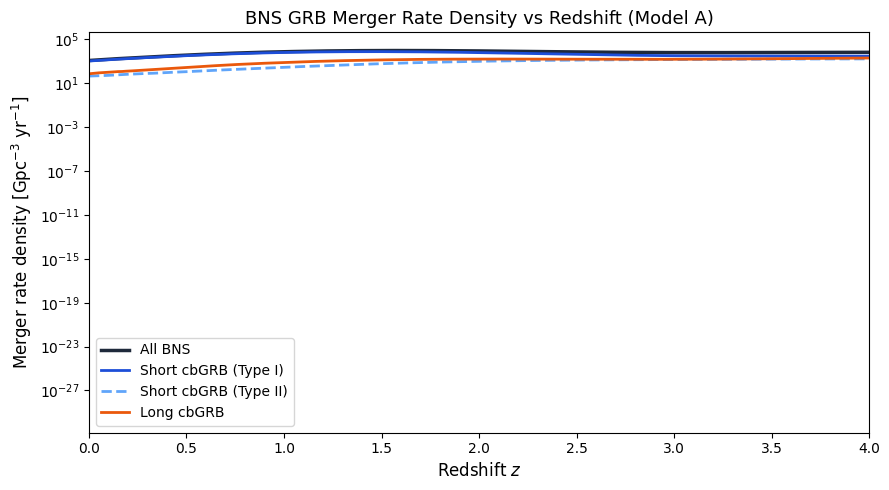

In [95]:
fig, ax = plt.subplots(figsize=(9, 5))

styles_bns = {
    'All BNS':               ('#1E293B', '-',  2.5),
    'Short cbGRB (Type I)':  ('#1D4ED8', '-',  2.0),
    'Short cbGRB (Type II)': ('#60A5FA', '--', 2.0),
    'Long cbGRB':            ('#EA580C', '-',  2.0),
}
for label, (c, ls, lw) in styles_bns.items():
    ax.plot(redshifts, merger_rates_BNS[label], color=c, ls=ls, lw=lw, label=label)

ax.set_xlim(0, 4); ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('BNS GRB Merger Rate Density vs Redshift (Model A)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. BHNS: Load Data & Classify (Foucart, a=0.5)

BH spin `a = 0.5` as fiducial. The Foucart (2012) disk mass formula with physical  
disruption pre-check determines whether each BHNS merger produces a GRB.

In [96]:
def r_isco(a_BH):
    Z1 = 1 + (1 - a_BH**2)**(1/3) * ((1 + a_BH)**(1/3) + (1 - a_BH)**(1/3))
    Z2 = np.sqrt(3*a_BH**2 + Z1**2)
    return 3 + Z2 - np.sign(a_BH + 1e-10) * np.sqrt((3 - Z1)*(3 + Z1 + 2*Z2))

def foucart_disk_mass(M_BH, M_NS, a_BH=0.0, R_NS_km=11.0):
    G = 6.674e-11; c = 3e8; Msun = 1.989e30
    q_r      = M_NS / M_BH
    f_roche  = 0.49 * q_r**(2/3) / (0.6 * q_r**(2/3) + np.log(1 + q_r**(1/3)))
    r_tidal  = (R_NS_km * 1e3) / f_roche
    r_ISCO   = r_isco(a_BH) * G * M_BH * Msun / c**2
    disrupted = r_tidal > r_ISCO
    C_NS  = G * M_NS * Msun / (R_NS_km * 1e3 * c**2)
    eta   = M_NS * M_BH / (M_NS + M_BH)**2
    r_hat = r_isco(a_BH) * M_BH / (M_BH + M_NS)
    M_disk = np.maximum(0.0, 0.406*(1-2*C_NS)/eta**(1/3) - 0.139*r_hat*C_NS + 0.255) * M_NS
    return np.where(disrupted, M_disk, 0.0)

path_BHNS = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BHNS_A.h5'
with h5.File(path_BHNS, 'r') as f:
    fDCO = f['doubleCompactObjects']
    M_BH_all     = fDCO['M1'][...].squeeze()
    M_NS_all     = fDCO['M2'][...].squeeze()
    weights_BHNS = fDCO['weight'][...].squeeze()
    Z_BHNS_all   = fDCO['Metallicity1'][...].squeeze()
    merges_BHNS  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_BHNS      = fDCO['tc'][...].squeeze()
    tform_BHNS   = fDCO['tform'][...].squeeze()
    stype1       = fDCO['stellarType1'][...].squeeze()

# correct BH/NS assignment
is_BH1   = (stype1 == 14)
M1_orig  = M_BH_all.copy(); M2_orig = M_NS_all.copy()
M_BH_all = np.where(is_BH1, M1_orig, M2_orig)
M_NS_all = np.where(is_BH1, M2_orig, M1_orig)

mask_BHNS = (merges_BHNS == 1)
BH = M_BH_all[mask_BHNS]; NS = M_NS_all[mask_BHNS]
M_disk     = foucart_disk_mass(BH, NS, a_BH=0.5)

# Gottlieb Figure 2 BHNS classes (fiducial spin a=0.5)
no_BHNS    = (M_disk == 0.0)                     # No disruption -> no GRB
short_BHNS = (M_disk > 0.0) & (M_disk < 0.1)    # Small disk -> short cbGRB
long_BHNS  = (M_disk >= 0.1)                     # Massive disk -> long cbGRB

delay_BHNS = (tform_BHNS + tc_BHNS)[mask_BHNS]
Z_BHNS     = Z_BHNS_all[mask_BHNS]
w_BHNS     = weights_BHNS[mask_BHNS]

print(f"Merging BHNS: {mask_BHNS.sum():,}")
print(f"No GRB:       {no_BHNS.sum():,}  ({100*no_BHNS.mean():.1f}%)")
print(f"Short cbGRB:  {short_BHNS.sum():,}  ({100*short_BHNS.mean():.1f}%)")
print(f"Long  cbGRB:  {long_BHNS.sum():,}  ({100*long_BHNS.mean():.1f}%)")


Merging BHNS: 1,525,553
No GRB:       1,413,206  (92.6%)
Short cbGRB:  0  (0.0%)
Long  cbGRB:  112,347  (7.4%)


## 7. BHNS Merger Rate Density

In [97]:
meanMassEvolved_BHNS = 77708655   # M_sun (same simulation setup)
n_formed_BHNS        = sfr / meanMassEvolved_BHNS

merger_rates_BHNS = {}
classes_BHNS = [
    ('Short cbGRB (a=0.5)', short_BHNS),
    ('Long cbGRB (a=0.5)',  long_BHNS),
    ('All BHNS',            np.ones(len(delay_BHNS), dtype=bool)),
]
for label, mask_grb in classes_BHNS:
    print(f"Computing {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[mask_grb], delay_BHNS[mask_grb], w_BHNS[mask_grb],
    )
    merger_rates_BHNS[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc^-3 yr^-1")


Computing Short cbGRB (a=0.5) (0 systems)...
  z=0: 0.0  |  z=1: 0.0  Gpc^-3 yr^-1
Computing Long cbGRB (a=0.5) (112,347 systems)...
  z=0: 632.2  |  z=1: 3,319.6  Gpc^-3 yr^-1
Computing All BHNS (1,525,553 systems)...
  z=0: 2246.6  |  z=1: 12,204.3  Gpc^-3 yr^-1


## 7b. BHNS Spin Sensitivity on Long cbGRB Rate

BH spin is the dominant uncertainty for BHNS classification. The same BHNS population  
is re-classified with the Foucart (2012) formula for `a = 0.0, 0.5, 0.7` and the  
full cosmic rate is recomputed for each case.  
This directly answers: *how much does the long cbGRB rate prediction depend on the unknown BH spin?*

a=0.0: Long cbGRB = 16,428  (1.1%)
  z=0: 199.4  |  z=1: 1,166.4  Gpc⁻³ yr⁻¹
a=0.5: Long cbGRB = 112,347  (7.4%)
  z=0: 632.2  |  z=1: 3,319.6  Gpc⁻³ yr⁻¹
a=0.7: Long cbGRB = 342,240  (22.4%)
  z=0: 1138.5  |  z=1: 5,798.1  Gpc⁻³ yr⁻¹


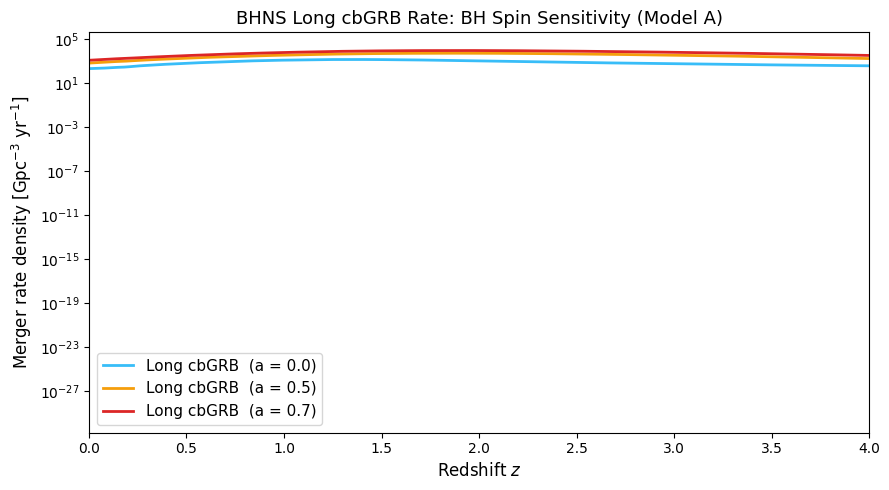

In [98]:
spin_colors = {0.0: '#38BDF8', 0.5: '#F59E0B', 0.7: '#DC2626'}
merger_rates_BHNS_spin = {}

for a in [0.0, 0.5, 0.7]:
    M_disk_a = foucart_disk_mass(BH, NS, a_BH=a)
    long_a   = (M_disk_a >= 0.1)
    print(f"a={a}: Long cbGRB = {long_a.sum():,}  ({100*long_a.mean():.1f}%)")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BHNS, dPdlogZ, metallicities, p_draw,
        Z_BHNS[long_a], delay_BHNS[long_a], w_BHNS[long_a],
    )
    merger_rates_BHNS_spin[a] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")

fig, ax = plt.subplots(figsize=(9, 5))
for a, color in spin_colors.items():
    ax.plot(redshifts, merger_rates_BHNS_spin[a], color=color, lw=2,
            label=f'Long cbGRB  (a = {a})')
ax.set_xlim(0, 4)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
ax.set_title('BHNS Long cbGRB Rate: BH Spin Sensitivity (Model A)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bhns_spin_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5b. BNS M_crit Sensitivity (EOS Uncertainty)

The critical total mass `M_crit = 2.8 M☉` separating HMNS-powered short cbGRBs from  
BH-disk systems is uncertain by ±0.2 M☉ depending on the neutron star equation of state.  
Vary from 2.6–3.0 M☉ to show the resulting uncertainty band on the short and long cbGRB rates.  
The solid black line is the fiducial value used throughout the analysis.

M_crit=2.6: Short=189,138 (81.1%)  Long=43,999 (18.9%)
M_crit=2.8: Short=189,855 (81.4%)  Long=43,282 (18.6%)
M_crit=3.0: Short=203,424 (87.3%)  Long=29,713 (12.7%)


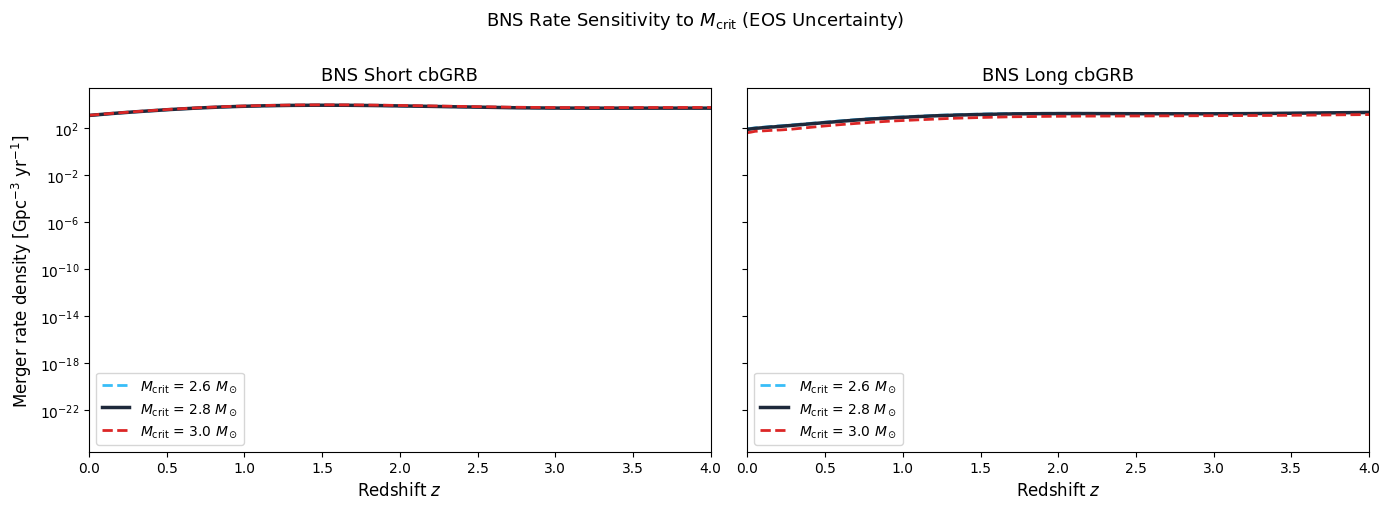

In [99]:
mcrit_colors = {2.6: '#38BDF8', 2.8: '#1E293B', 3.0: '#DC2626'}
mcrit_styles = {2.6: '--',         2.8: '-',      3.0: '--'}
rates_mcrit_short = {}
rates_mcrit_long  = {}

for Mc in [2.6, 2.8, 3.0]:
    s = (M_tot < Mc) | ((M_tot >= Mc) & (q < 1.2))
    l = (M_tot >= Mc) & (q >= 1.2)
    print(f"M_crit={Mc}: Short={s.sum():,} ({100*s.mean():.1f}%)  Long={l.sum():,} ({100*l.mean():.1f}%)")
    rates_mcrit_short[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[s], delay_BNS[s], w_BNS[s],
    )
    rates_mcrit_long[Mc] = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS[l], delay_BNS[l], w_BNS[l],
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for Mc in [2.6, 2.8, 3.0]:
    c, ls = mcrit_colors[Mc], mcrit_styles[Mc]
    lw = 2.5 if Mc == 2.8 else 2
    axes[0].plot(redshifts, rates_mcrit_short[Mc], color=c, ls=ls, lw=lw,
                 label=f'$M_{{\\mathrm{{crit}}}}$ = {Mc} $M_\\odot$')
    axes[1].plot(redshifts, rates_mcrit_long[Mc],  color=c, ls=ls, lw=lw,
                 label=f'$M_{{\\mathrm{{crit}}}}$ = {Mc} $M_\\odot$')

for ax, title in zip(axes, ['Short cbGRB', 'Long cbGRB']):
    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {title}', fontsize=13)
    ax.legend(fontsize=10)
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.suptitle(r'BNS Rate Sensitivity to $M_{\mathrm{crit}}$ (EOS Uncertainty)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_mcrit_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5c. Model K vs Model A: Binary Physics Uncertainty

Model K uses a lower common envelope efficiency (α_CE = 0.5) vs the fiducial Model A (α_CE = 1.0).  
Comparing the full cosmic rates between models shows how sensitive the predicted GRB rates are  
to uncertain binary evolution physics - independent of the EOS or BH spin assumptions.

Both short and long cbGRB rates are compared, with the shaded band showing the model uncertainty range.

Model K - Merging BNS: 234,963
Short cbGRB: 191,290  (81.4%)
Long  cbGRB: 43,673  (18.6%)
Computing Model K Short cbGRB (191,290 systems)...
  z=0: 1304.8  |  z=1: 7,627.6  Gpc⁻³ yr⁻¹
Computing Model K Long cbGRB (43,673 systems)...
  z=0: 200.6  |  z=1: 1,405.8  Gpc⁻³ yr⁻¹
Computing Model K All BNS (234,963 systems)...
  z=0: 1505.4  |  z=1: 9,033.4  Gpc⁻³ yr⁻¹


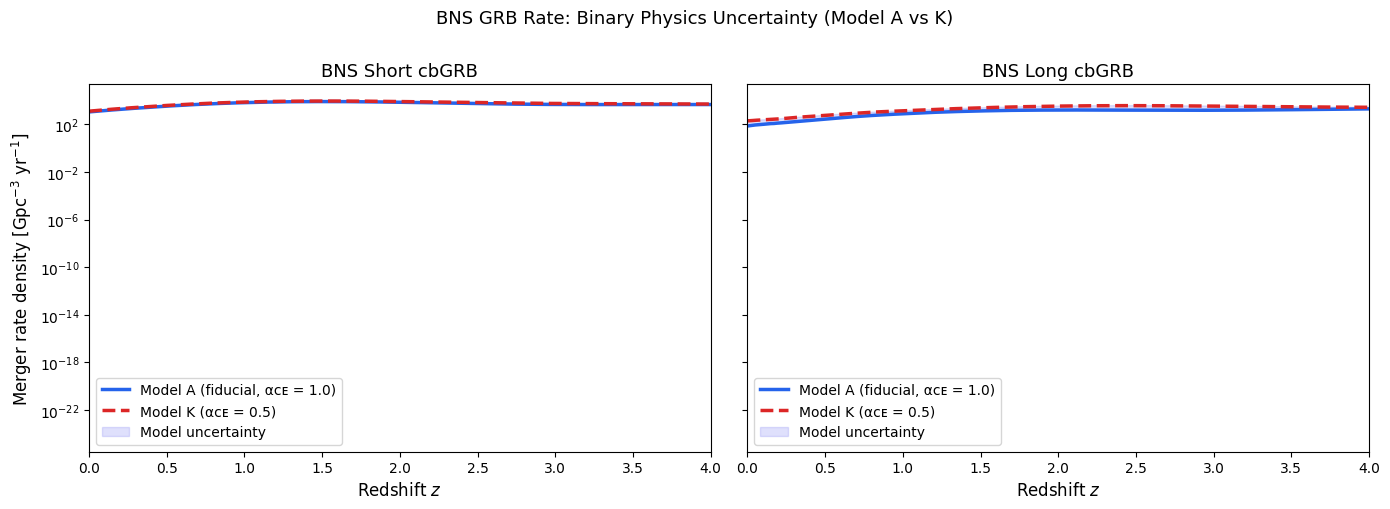

In [100]:
path_K = '/Users/josephrodriguez/research visualization/Data/COMPASCompactOutput_BNS_K.h5'
with h5.File(path_K, 'r') as f:
    fDCO = f['doubleCompactObjects']
    mass1_K   = fDCO['M1'][...].squeeze()
    mass2_K   = fDCO['M2'][...].squeeze()
    weights_K = fDCO['weight'][...].squeeze()
    Z_K_all   = fDCO['Metallicity1'][...].squeeze()
    merges_K  = fDCO['mergesInHubbleTimeFlag'][...].squeeze()
    tc_K      = fDCO['tc'][...].squeeze()
    tform_K   = fDCO['tform'][...].squeeze()

mask_K  = (merges_K == 1)
M_tot_K = mass1_K[mask_K] + mass2_K[mask_K]
q_K     = np.maximum(mass1_K[mask_K], mass2_K[mask_K]) / np.minimum(mass1_K[mask_K], mass2_K[mask_K])

short_K = (M_tot_K < 2.8) | ((M_tot_K >= 2.8) & (q_K < 1.2))
long_K  = (M_tot_K >= 2.8) & (q_K >= 1.2)

delay_K = (tform_K + tc_K)[mask_K]
Z_K     = Z_K_all[mask_K]
w_K     = weights_K[mask_K]

print(f"Model K - Merging BNS: {mask_K.sum():,}")
print(f"Short cbGRB: {short_K.sum():,}  ({100*short_K.mean():.1f}%)")
print(f"Long  cbGRB: {long_K.sum():,}  ({100*long_K.mean():.1f}%)")

# Compute rates for Model K (reuses n_formed_BNS - same meanMassEvolved)
merger_rates_K = {}
for label, mask_grb in [('Short cbGRB', short_K),
                          ('Long cbGRB',  long_K),
                          ('All BNS',     np.ones(len(delay_K), dtype=bool))]:
    print(f"Computing Model K {label} ({mask_grb.sum():,} systems)...")
    rate = compute_merger_rate(
        redshifts, times, time_first_SF, n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_K[mask_grb], delay_K[mask_grb], w_K[mask_grb],
    )
    merger_rates_K[label] = rate
    print(f"  z=0: {rate[0]:.1f}  |  z=1: {rate[np.argmin(np.abs(redshifts-1))]:,.1f}  Gpc\u207b\u00b3 yr\u207b\u00b9")

# ── Plot Model A vs Model K ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, label in zip(axes, ['Short cbGRB', 'Long cbGRB']):
    rA = merger_rates_BNS[label]
    rK = merger_rates_K[label]
    ax.plot(redshifts, rA, color='#2563EB', lw=2.5, label='Model A (fiducial, \u03b1\u1D04\u1D07 = 1.0)')
    ax.plot(redshifts, rK, color='#DC2626',   lw=2.5, ls='--', label='Model K (\u03b1\u1D04\u1D07 = 0.5)')
    ax.fill_between(redshifts,
                    np.minimum(rA, rK), np.maximum(rA, rK),
                    alpha=0.20, color='#6366F1', label='Model uncertainty')
    ax.set_xlim(0, 4)
    ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.set_title(f'BNS {label}', fontsize=13)
    ax.legend(fontsize=10)

axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.suptitle('BNS GRB Rate: Binary Physics Uncertainty (Model A vs K)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_bns_model_ak.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Combined BNS + BHNS Plot

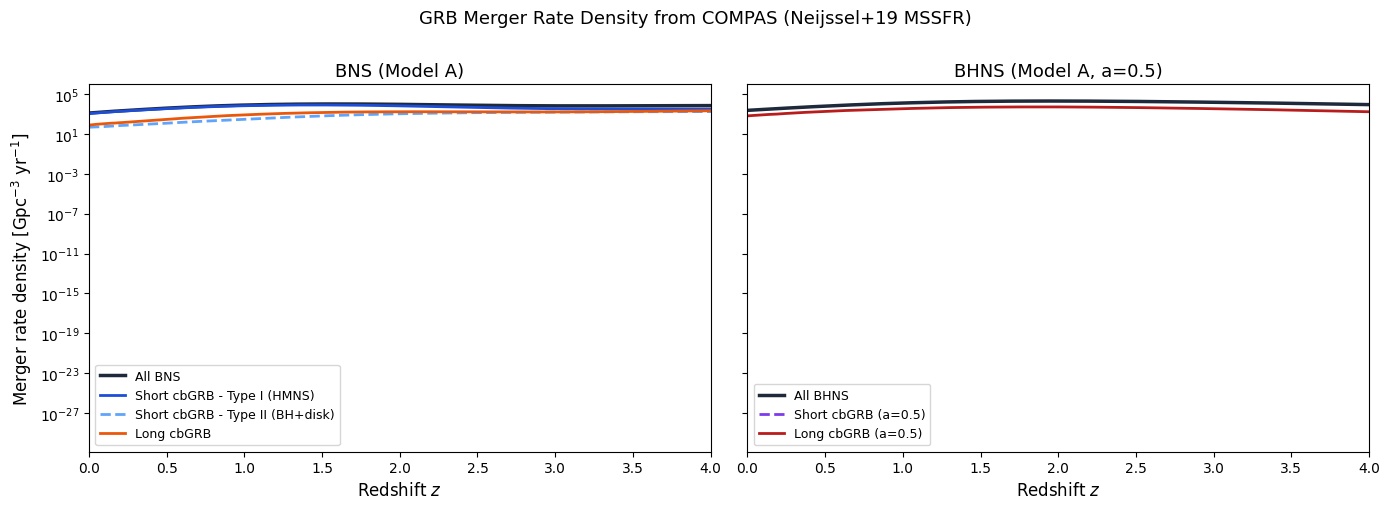

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# BNS panel
ax = axes[0]
ax.plot(redshifts, merger_rates_BNS['All BNS'],               color='#1E293B', lw=2.5, ls='-',  label='All BNS')
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],  color='#1D4ED8', lw=2.0, ls='-',  label='Short cbGRB - Type I (HMNS)')
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'], color='#60A5FA', lw=2.0, ls='--', label='Short cbGRB - Type II (BH+disk)')
ax.plot(redshifts, merger_rates_BNS['Long cbGRB'],            color='#EA580C', lw=2.0, ls='-',  label='Long cbGRB')
ax.set_title('BNS (Model A)', fontsize=13)

# BHNS panel
ax = axes[1]
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],           color='#1E293B', lw=2.5, ls='-',  label='All BHNS')
ax.plot(redshifts, merger_rates_BHNS['Short cbGRB (a=0.5)'],color='#7C3AED', lw=2.0, ls='--', label='Short cbGRB (a=0.5)')
ax.plot(redshifts, merger_rates_BHNS['Long cbGRB (a=0.5)'], color='#B91C1C', lw=2.0, ls='-',  label='Long cbGRB (a=0.5)')
ax.set_title('BHNS (Model A, a=0.5)', fontsize=13)

for ax in axes:
    ax.set_xlim(0, 4); ax.set_yscale('log')
    ax.set_xlabel('Redshift $z$', fontsize=12)
    ax.legend(fontsize=9)
axes[0].set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=12)
plt.suptitle('GRB Merger Rate Density from COMPAS (Neijssel+19 MSSFR)', fontsize=13, y=1.01)
plt.tight_layout(); plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_combined_bns_bhns.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Unified Figure 2 Rate Plot: All cbGRB Classes

Full Gottlieb et al. (2023) Figure 2 classification across cosmic time.
All five physically distinct outcomes are shown on a single axis:
- **BNS Type I sGRB** (HMNS-powered): M_tot < M_crit
- **BNS Type II sGRB** (BH + light disk): M_tot >= M_crit, q < 1.2
- **BNS lGRB** (BH + massive disk): M_tot >= M_crit, q >= 1.2
- **BHNS sGRB** (small disk, Foucart a=0.5): 0 < M_disk < 0.1 M_sun
- **BHNS lGRB** (massive disk, Foucart a=0.5): M_disk >= 0.1 M_sun

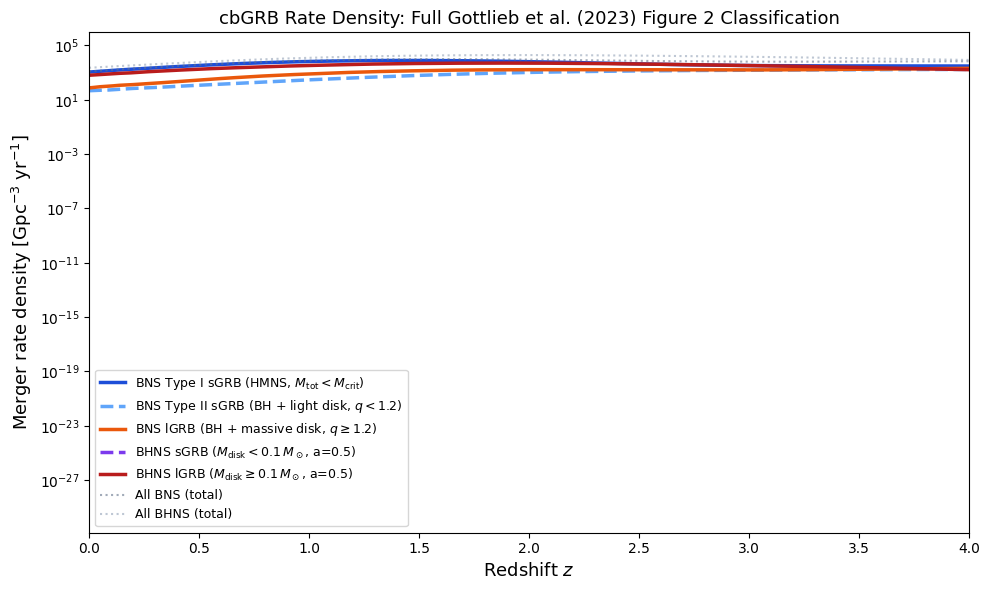

In [102]:
fig, ax = plt.subplots(figsize=(10, 6))

# ---- BNS classes ----
ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type I)'],
        color='#1D4ED8', lw=2.5, ls='-',
        label=r'BNS Type I sGRB (HMNS, $M_\mathrm{tot} < M_\mathrm{crit}$)')

ax.plot(redshifts, merger_rates_BNS['Short cbGRB (Type II)'],
        color='#60A5FA', lw=2.5, ls='--',
        label=r'BNS Type II sGRB (BH + light disk, $q < 1.2$)')

ax.plot(redshifts, merger_rates_BNS['Long cbGRB'],
        color='#EA580C', lw=2.5, ls='-',
        label=r'BNS lGRB (BH + massive disk, $q \geq 1.2$)')

# ---- BHNS classes (a=0.5 fiducial) ----
ax.plot(redshifts, merger_rates_BHNS['Short cbGRB (a=0.5)'],
        color='#7C3AED', lw=2.5, ls='--',
        label=r'BHNS sGRB ($M_\mathrm{disk} < 0.1\,M_\odot$, a=0.5)')

ax.plot(redshifts, merger_rates_BHNS['Long cbGRB (a=0.5)'],
        color='#B91C1C', lw=2.5, ls='-',
        label=r'BHNS lGRB ($M_\mathrm{disk} \geq 0.1\,M_\odot$, a=0.5)')

# ---- Total merger rates (reference, thin dashed grey) ----
ax.plot(redshifts, merger_rates_BNS['All BNS'],
        color='#64748B', lw=1.5, ls=':', alpha=0.6, label='All BNS (total)')
ax.plot(redshifts, merger_rates_BHNS['All BHNS'],
        color='#94A3B8', lw=1.5, ls=':', alpha=0.6, label='All BHNS (total)')

ax.set_xlim(0, 4)
ax.set_yscale('log')
ax.set_xlabel('Redshift $z$', fontsize=13)
ax.set_ylabel(r'Merger rate density [Gpc$^{-3}$ yr$^{-1}$]', fontsize=13)
ax.set_title('cbGRB Rate Density: Full Gottlieb et al. (2023) Figure 2 Classification',
             fontsize=13)
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/rate_figure2_unified.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Mass Distributions at Redshift Slices

How does the merging BNS mass distribution shift with cosmic time? At high redshift
low-metallicity star formation dominates, which can change the typical NS mass and
shift the long vs short cbGRB balance. Here each binary is weighted by its
contribution to the merger rate at a specific target redshift.

In [103]:
def per_system_rate_weights(z_target, redshifts, times, time_first_SF,
                             n_formed, dPdlogZ, metallicities, p_draw,
                             COMPAS_Z, COMPAS_delay_times, COMPAS_weights):
    """
    Per-system contribution to the merger rate at z_target.
    Mirrors compute_merger_rate but returns an array of individual weights
    instead of summing them, so histograms can be weighted by rate contribution.
    """
    redshift_step = redshifts[1] - redshifts[0]
    times_to_z    = interp1d(times, redshifts)

    j_target = np.argmin(np.abs(redshifts - z_target))
    t_merge  = times[j_target]

    Z_bins = np.clip(np.digitize(COMPAS_Z, metallicities), 0, len(metallicities) - 1)
    t_min  = max(time_first_SF, times.min())

    out    = np.zeros(len(COMPAS_weights))
    t_form = t_merge - COMPAS_delay_times
    valid  = t_form >= t_min

    if valid.any():
        z_form     = times_to_z(t_form[valid])
        z_form_idx = np.clip(np.ceil(z_form / redshift_step).astype(int),
                             0, len(redshifts) - 1)
        out[valid] = (n_formed[z_form_idx]
                      * dPdlogZ[z_form_idx, Z_bins[valid]]
                      / p_draw
                      * COMPAS_weights[valid])
    return out


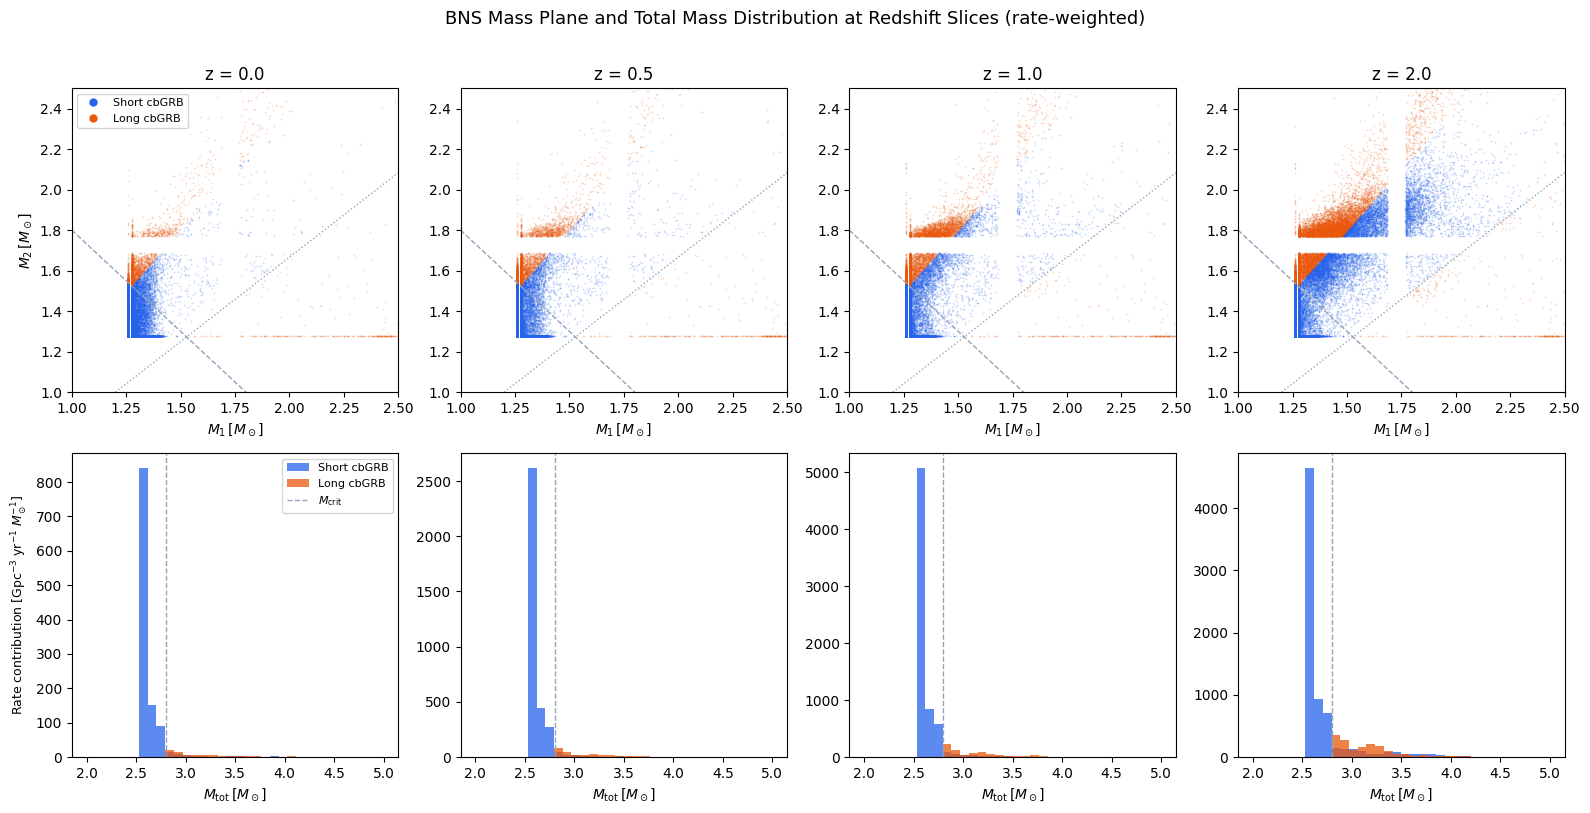

In [104]:
M1_m = mass1[mask_BNS]
M2_m = mass2[mask_BNS]

z_slices  = [0.0, 0.5, 1.0, 2.0]
bins_mtot = np.linspace(2.0, 5.0, 35)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, z_s in enumerate(z_slices):
    w = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )

    # --- Top row: M1 vs M2 scatter (top 40 % rate contributors only) ---
    ax = axes[0, col]
    w_thresh = np.percentile(w[w > 0], 60) if (w > 0).any() else 0.0
    vis = w >= w_thresh

    ax.scatter(M1_m[vis & short_BNS], M2_m[vis & short_BNS],
               s=1.5, c='#2563EB', alpha=0.25, linewidths=0)
    ax.scatter(M1_m[vis & long_BNS],  M2_m[vis & long_BNS],
               s=1.5, c='#EA580C', alpha=0.25, linewidths=0)
    # classification lines
    m_vals = np.linspace(1.0, 2.5, 200)
    ax.plot(m_vals, 2.8 - m_vals, color='#94A3B8', lw=1, ls='--')   # M_tot = 2.8
    ax.plot(m_vals, m_vals / 1.2,  color='#94A3B8', lw=1, ls=':')   # q = 1.2
    ax.set_xlim(1.0, 2.5); ax.set_ylim(1.0, 2.5)
    ax.set_title(f'z = {z_s}', fontsize=12)
    ax.set_xlabel(r'$M_1\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax.set_ylabel(r'$M_2\,[M_\odot]$', fontsize=10)
        from matplotlib.lines import Line2D
        ax.legend(handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#2563EB',
                   markersize=7, label='Short cbGRB'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#EA580C',
                   markersize=7, label='Long cbGRB'),
        ], fontsize=8)

    # --- Bottom row: M_tot histogram ---
    ax2 = axes[1, col]
    ax2.hist(M_tot[short_BNS], bins=bins_mtot, weights=w[short_BNS],
             color='#2563EB', alpha=0.75, label='Short cbGRB')
    ax2.hist(M_tot[long_BNS],  bins=bins_mtot, weights=w[long_BNS],
             color='#EA580C', alpha=0.75, label='Long cbGRB')
    ax2.axvline(2.8, color='#94A3B8', ls='--', lw=1,
                label=r'$M_\mathrm{crit}$')
    ax2.set_xlabel(r'$M_\mathrm{tot}\,[M_\odot]$', fontsize=10)
    if col == 0:
        ax2.set_ylabel(r'Rate contribution [Gpc$^{-3}$ yr$^{-1}$ $M_\odot^{-1}$]',
                       fontsize=9)
        ax2.legend(fontsize=8)

plt.suptitle('BNS Mass Plane and Total Mass Distribution at Redshift Slices '
             '(rate-weighted)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_mass_dist_redshift_slices.png', dpi=150, bbox_inches='tight')
plt.show()


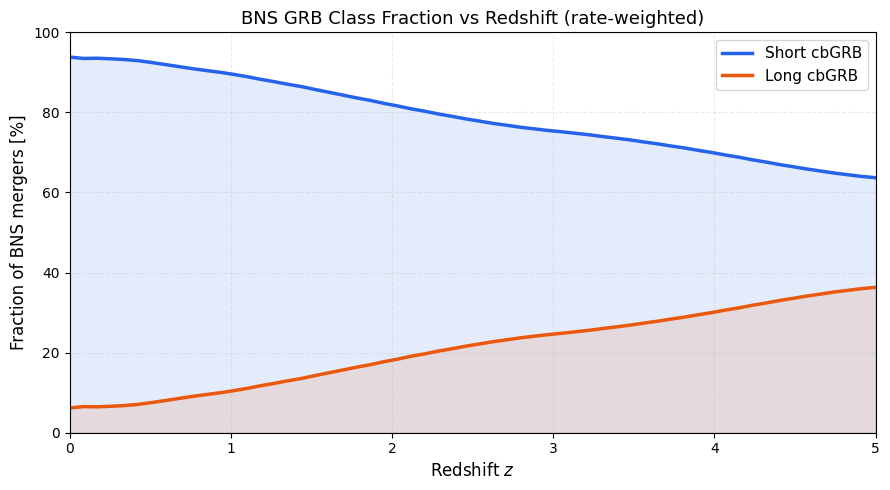

In [105]:
z_arr      = np.linspace(0.0, 5.0, 60)
frac_short = []
frac_long  = []

for z_s in z_arr:
    w     = per_system_rate_weights(
        z_s, redshifts, times, time_first_SF,
        n_formed_BNS, dPdlogZ, metallicities, p_draw,
        Z_BNS, delay_BNS, w_BNS,
    )
    r_tot = w.sum()
    if r_tot > 0:
        frac_short.append(100 * w[short_BNS].sum() / r_tot)
        frac_long.append( 100 * w[long_BNS].sum()  / r_tot)
    else:
        frac_short.append(np.nan)
        frac_long.append(np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z_arr, frac_short, color='#2563EB', lw=2.5, label='Short cbGRB')
ax.plot(z_arr, frac_long,  color='#EA580C', lw=2.5, label='Long cbGRB')
ax.fill_between(z_arr, frac_short, alpha=0.12, color='#2563EB')
ax.fill_between(z_arr, frac_long,  alpha=0.12, color='#EA580C')
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)
ax.set_xlabel('Redshift $z$', fontsize=12)
ax.set_ylabel('Fraction of BNS mergers [%]', fontsize=12)
ax.set_title('BNS GRB Class Fraction vs Redshift (rate-weighted)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25, ls='--')
plt.tight_layout()
plt.savefig('/Users/josephrodriguez/research visualization/plots/bns_grb_fraction_vs_redshift.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Export

In [106]:
np.save('/Users/josephrodriguez/research visualization/results/rates_BNS.npy',
        np.array([redshifts,
                  merger_rates_BNS['All BNS'],
                  merger_rates_BNS['Short cbGRB'],
                  merger_rates_BNS['Long cbGRB']]))

np.save('/Users/josephrodriguez/research visualization/results/rates_BHNS.npy',
        np.array([redshifts,
                  merger_rates_BHNS['All BHNS'],
                  merger_rates_BHNS['Long cbGRB (a=0.5)']]))

print("Rates saved to rates_BNS.npy and rates_BHNS.npy")

Rates saved to rates_BNS.npy and rates_BHNS.npy
